In [1]:
# Install if needed:
# pip install numpy scipy tensorflow matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
# ============================================================
# SYSTEM PARAMETERS (from the paper)
# ============================================================

# Powers
Pp = 60e-3          # Primary user transmit power = 60 mW
Pt = 100e-3         # Max secondary transmit power = 100 mW (assumed)
q  = 1e-3           # Interference threshold for primary (assumed)

# Noise
sigma2_s = 0.001    # Noise variance at secondary receiver
sigma2_e = 0.001    # Noise variance at eavesdropper

# Path loss
alpha = 1.7         # Path loss exponent

# Distances (in meters)
d_s = 10.0          # SU-Tx to SU-Rx
d_e = 20.0          # SU-Tx to eavesdropper
d_p = 10.0          # SU-Tx to PU-Rx
c_s = 20.0          # PU-Tx to SU-Rx
c_e = 20.0          # PU-Tx to eavesdropper

# Dataset sizes (from paper)
N_TOTAL = 600000    # Total samples (paper uses 6×10^5)
N_TRAIN = 500000    # Training
N_VAL   = 100000    # Validation
N_TEST  = 3000      # Testing

print("Parameters set.")

Parameters set.


In [4]:
# ============================================================
# STEP 3: GENERATE CHANNEL COEFFICIENTS
# ============================================================

def generate_channels(n_samples):
    """
    Generate channel coefficients according to the paper:
    
    h_i = rho_i * sqrt(d_i^(-alpha))   for i = s, e, p
    g_j = rho_j * sqrt(c_j^(-alpha))   for j = s, e
    
    where rho ~ CN(0,1)  (complex Gaussian)
    """
    
    # Complex Gaussian random variables
    rho_s = (np.random.randn(n_samples) + 1j*np.random.randn(n_samples)) / np.sqrt(2)
    rho_p = (np.random.randn(n_samples) + 1j*np.random.randn(n_samples)) / np.sqrt(2)
    rho_e = (np.random.randn(n_samples) + 1j*np.random.randn(n_samples)) / np.sqrt(2)
    rho_gs = (np.random.randn(n_samples) + 1j*np.random.randn(n_samples)) / np.sqrt(2)
    rho_ge = (np.random.randn(n_samples) + 1j*np.random.randn(n_samples)) / np.sqrt(2)
    
    # Apply path loss
    h_s = rho_s * np.sqrt(d_s**(-alpha))
    h_p = rho_p * np.sqrt(d_p**(-alpha))
    h_e = rho_e * np.sqrt(d_e**(-alpha))
    g_s = rho_gs * np.sqrt(c_s**(-alpha))
    g_e = rho_ge * np.sqrt(c_e**(-alpha))
    
    return h_s, h_p, h_e, g_s, g_e


# Generate all channels at once
h_s, h_p, h_e, g_s, g_e = generate_channels(N_TOTAL)

print("Channel shapes:", h_s.shape)
print("Sample |h_s|:", np.abs(h_s[:5]))

Channel shapes: (600000,)
Sample |h_s|: [0.18903378 0.01765945 0.09727706 0.15632982 0.14568989]


In [5]:
# ============================================================
# STEP 4: TRADITIONAL OPTIMIZATION (Generates labels)
# ============================================================

def compute_optimal_power(h_s, h_p, h_e, g_s, g_e, 
                          Pp, Pt, q, sigma2_s, sigma2_e):
    """
    Solve the secrecy rate maximization problem:
    
    max_{Ps}  (1 + Ps|hs|^2/(Pp|gs|^2 + sigma2_s))
              -----------------------------------------
              (1 + Ps|he|^2/(Pp|ge|^2 + sigma2_e))
    
    s.t.  Ps|hp|^2 <= q
          Ps <= Pt
          Ps >= 0
    """
    
    # Precompute constants
    a = np.abs(h_s)**2 / (Pp * np.abs(g_s)**2 + sigma2_s)
    b = np.abs(h_e)**2 / (Pp * np.abs(g_e)**2 + sigma2_e)
    
    # Upper bound from constraints
    Ps_max_interference = q / np.abs(h_p)**2
    Ps_upper = min(Ps_max_interference, Pt)
    
    if Ps_upper <= 0:
        return 0.0
    
    # Objective: maximize ratio -> minimize negative ratio
    def objective(Ps):
        return -(1 + a * Ps) / (1 + b * Ps)
    
    # Solve with bounds
    result = minimize(
        objective,
        x0=Ps_upper / 2,
        bounds=[(0, Ps_upper)],
        method='L-BFGS-B'
    )
    
    return result.x[0]


# Test on a few samples first
print("Testing optimization on 5 samples...")
for i in range(5):
    Ps_opt = compute_optimal_power(
        h_s[i], h_p[i], h_e[i], g_s[i], g_e[i],
        Pp, Pt, q, sigma2_s, sigma2_e
    )
    print(f"Sample {i}: Ps* = {Ps_opt*1000:.4f} mW")

Testing optimization on 5 samples...
Sample 0: Ps* = 53.5460 mW
Sample 1: Ps* = 0.0000 mW
Sample 2: Ps* = 100.0000 mW
Sample 3: Ps* = 32.4064 mW
Sample 4: Ps* = 100.0000 mW


In [7]:
# ============================================================
# STEP 5: GENERATE FULL DATASET
# ============================================================

from tqdm import tqdm  # pip install tqdm

def generate_dataset(h_s, h_p, h_e, g_s, g_e, 
                     Pp, Pt, q, sigma2_s, sigma2_e):
    """Generate labels for all samples."""
    N = len(h_s)
    Ps_opt = np.zeros(N)
    
    for i in tqdm(range(N), desc="Solving optimization"):
        Ps_opt[i] = compute_optimal_power(
            h_s[i], h_p[i], h_e[i], g_s[i], g_e[i],
            Pp, Pt, q, sigma2_s, sigma2_e
        )
    
    return Ps_opt


# For testing, use a smaller dataset first
N_SMALL = 5000
print(f"Generating small dataset of {N_SMALL} samples...")

Ps_opt_small = generate_dataset(
    h_s[:N_SMALL], h_p[:N_SMALL], h_e[:N_SMALL], 
    g_s[:N_SMALL], g_e[:N_SMALL],
    Pp, Pt, q, sigma2_s, sigma2_e
)

print("Done! Sample labels:", Ps_opt_small[:5])

Generating small dataset of 5000 samples...


Solving optimization: 100%|██████████| 5000/5000 [00:17<00:00, 279.11it/s]

Done! Sample labels: [0.05354605 0.         0.1        0.03240636 0.1       ]


In [8]:
# ============================================================
# STEP 6: PREPARE INPUT/OUTPUT FOR NN
# ============================================================

def prepare_inputs(h_s, h_p, h_e, g_s, g_e, 
                   eps_s=0.0, eps_e=0.0, eps_p=0.0):
    """
    Prepare input features for NN:
    S = [|h_s|, |h_p|, |h_e|, |g_s|, |g_e|, eps_s, eps_e, eps_p]
    """
    N = len(h_s)
    
    # For perfect CSI: eps = 0
    if np.isscalar(eps_s):
        eps_s = np.full(N, eps_s)
        eps_e = np.full(N, eps_e)
        eps_p = np.full(N, eps_p)
    
    inputs = np.column_stack([
        np.abs(h_s),
        np.abs(h_p),
        np.abs(h_e),
        np.abs(g_s),
        np.abs(g_e),
        eps_s,
        eps_e,
        eps_p
    ])
    
    return inputs


# Prepare inputs (perfect CSI: eps = 0)
X = prepare_inputs(h_s[:N_SMALL], h_p[:N_SMALL], h_e[:N_SMALL],
                   g_s[:N_SMALL], g_e[:N_SMALL])

# Output
y = Ps_opt_small

print("Input shape:", X.shape)   # (N, 8)
print("Output shape:", y.shape)  # (N,)

# Normalize inputs (important for NN training!)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-10  # avoid division by zero
X_norm = (X - X_mean) / X_std

# Normalize output
y_mean = y.mean()
y_std = y.std() + 1e-10
y_norm = (y - y_mean) / y_std

print("Normalized input mean:", X_norm.mean(axis=0).round(4))
print("Normalized input std:", X_norm.std(axis=0).round(4))

Input shape: (5000, 8)
Output shape: (5000,)
Normalized input mean: [-0.  0.  0.  0. -0.  0.  0.  0.]
Normalized input std: [1. 1. 1. 1. 1. 0. 0. 0.]


In [9]:
# ============================================================
# STEP 7: SPLIT DATA
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y_norm, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

Training set:   (3500, 8)
Validation set: (750, 8)
Test set:       (750, 8)


In [10]:
# ============================================================
# STEP 8: BUILD THE NN MODEL
# ============================================================

def build_nn_model(input_dim=8, hidden_layers=2, neurons=100, 
                   learning_rate=1e-4, reg_lambda=5e-4):
    """
    Build NN with:
    - Input layer: 8 features
    - 2 hidden layers with 100 neurons each
    - ReLU activation
    - Output layer: 1 neuron (linear)
    - L2 regularization
    """
    model = models.Sequential()
    
    # Input layer + first hidden layer
    model.add(layers.Dense(
        neurons, 
        activation='relu',
        input_shape=(input_dim,),
        kernel_regularizer=regularizers.l2(reg_lambda)
    ))
    
    # Additional hidden layers
    for _ in range(hidden_layers - 1):
        model.add(layers.Dense(
            neurons,
            activation='relu',
            kernel_regularizer=regularizers.l2(reg_lambda)
        ))
    
    # Output layer (linear)
    model.add(layers.Dense(1, activation='linear'))
    
    # Compile
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model


# Build the model
model = build_nn_model()
model.summary()

c:\Users\vedastus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,101 (43.36 KB)

 Trainable params: 11,101 (43.36 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ============================================================
# STEP 9: TRAIN THE NN
# ============================================================

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.5583 - mae: 0.5939 - val_loss: 0.3810 - val_mae: 0.4368 - learning_rate: 1.0000e-04
Epoch 2/200
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3363 - mae: 0.3994 - val_loss: 0.3171 - val_mae: 0.3785 - learning_rate: 1.0000e-04
Epoch 3/200
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2895 - mae: 0.3567 - val_loss: 0.2914 - val_mae: 0.3573 - learning_rate: 1.0000e-04
Epoch 4/200
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.2675 - mae: 0.3383 - val_loss: 0.2762 - val_mae: 0.3460 - learning_rate: 1.0000e-04
Epoch 5/200
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2530 - mae: 0.3260 - val_loss: 0.2642 - val_mae: 0.3364 - learning_rate: 1.0000e-04
Epoch 6/200
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2413 - mae: 0.3154 - val_loss: 0.2538 - val_mae: 0.3275 - learning_rate: 1.0000e-04
Epoch 7/200
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2309 - mae: 0.3058 - val_loss: 0.2445 - val_mae: 0.318

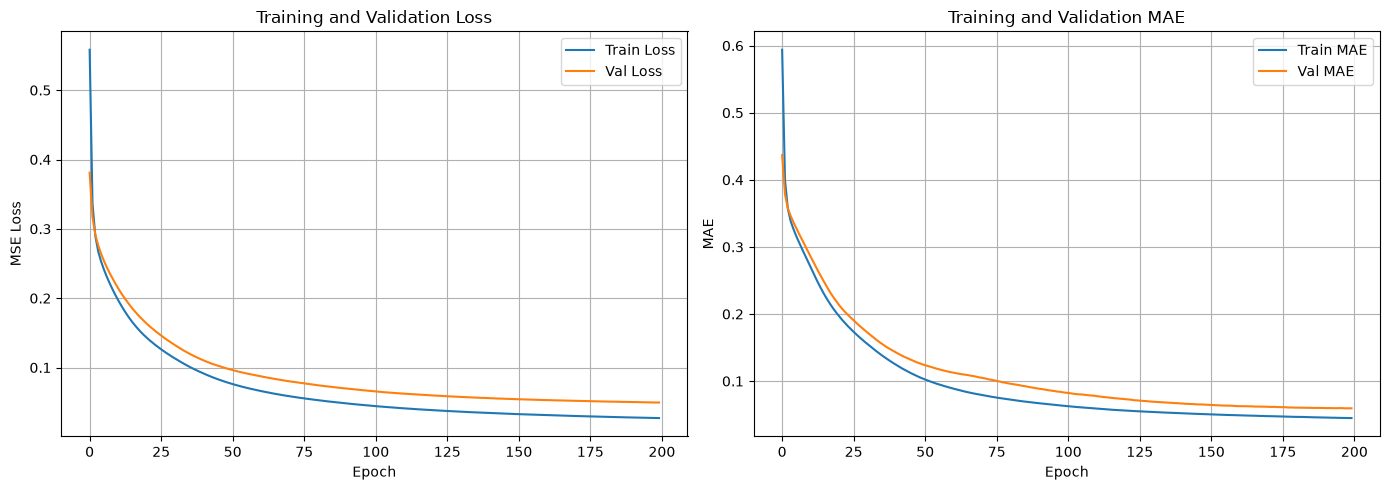

In [12]:
# ============================================================
# STEP 10: PLOT TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training and Validation MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [13]:
# ============================================================
# STEP 11: TEST THE NN
# ============================================================

# Predict
y_pred_norm = model.predict(X_test).flatten()

# Denormalize
y_pred = y_pred_norm * y_std + y_mean
y_true = y_test * y_std + y_mean

# Metrics
mse = np.mean((y_pred - y_true)**2)
mae = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(mse)

print("=" * 50)
print("TEST RESULTS")
print("=" * 50)
print(f"MSE:  {mse:.6e}")
print(f"MAE:  {mae:.6e}")
print(f"RMSE: {rmse:.6e}")

# Relative error
rel_error = np.abs(y_pred - y_true) / (np.abs(y_true) + 1e-10)
print(f"Mean relative error: {np.mean(rel_error)*100:.2f}%")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
TEST RESULTS
MSE:  4.728268e-05
MAE:  2.394094e-03
RMSE: 6.876240e-03
Mean relative error: 1075730128.35%


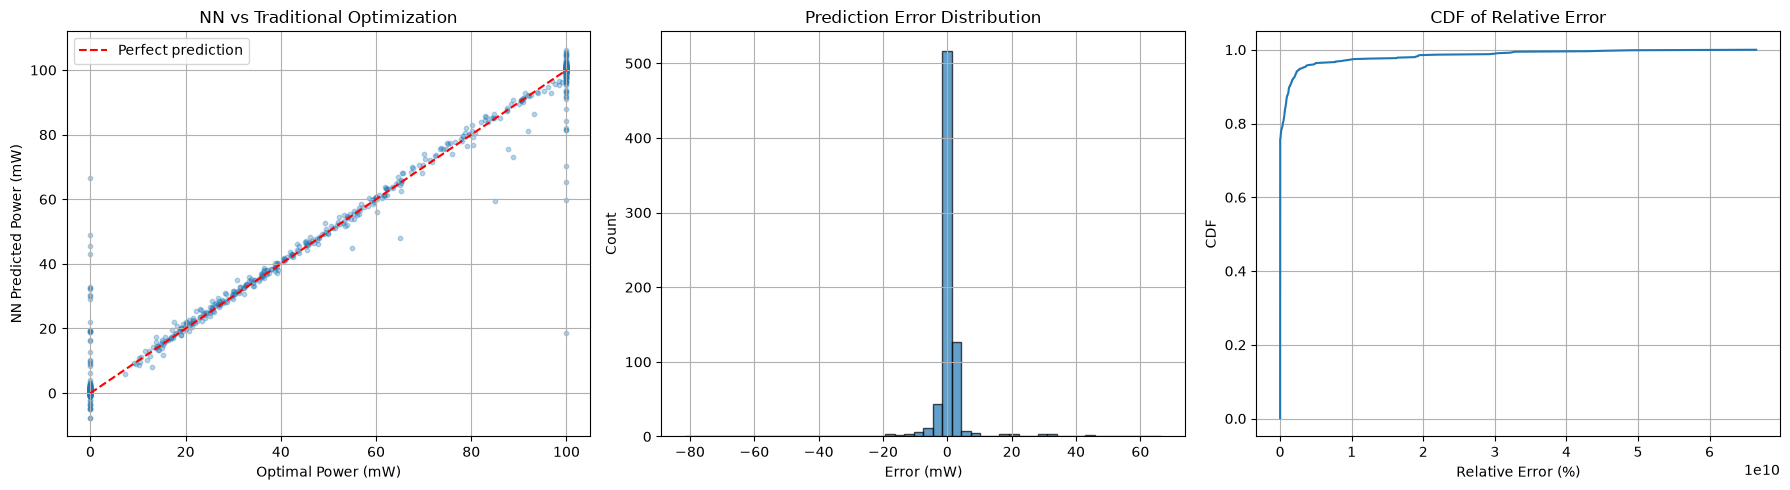

In [14]:
# ============================================================
# STEP 12: VISUALIZE RESULTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
axes[0].scatter(y_true*1000, y_pred*1000, alpha=0.3, s=10)
axes[0].plot([0, max(y_true)*1000], [0, max(y_true)*1000], 
             'r--', label='Perfect prediction')
axes[0].set_xlabel('Optimal Power (mW)')
axes[0].set_ylabel('NN Predicted Power (mW)')
axes[0].set_title('NN vs Traditional Optimization')
axes[0].legend()
axes[0].grid(True)

# Error histogram
errors = (y_pred - y_true) * 1000
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Error (mW)')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Error Distribution')
axes[1].grid(True)

# CDF of relative error
sorted_rel = np.sort(rel_error)
cdf = np.arange(1, len(sorted_rel)+1) / len(sorted_rel)
axes[2].plot(sorted_rel*100, cdf)
axes[2].set_xlabel('Relative Error (%)')
axes[2].set_ylabel('CDF')
axes[2].set_title('CDF of Relative Error')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()

In [15]:
# ============================================================
# STEP 13: COMPARE COMPUTATION TIME
# ============================================================

import time

# Test NN speed
N_timing = 1000

# NN inference time
start = time.time()
_ = model.predict(X_test[:N_timing], verbose=0)
nn_time = time.time() - start
print(f"NN inference time for {N_timing} samples: {nn_time:.4f} s")
print(f"  Per sample: {nn_time/N_timing*1e6:.2f} µs")

# Traditional optimization time (on small subset)
N_opt = 100
start = time.time()
for i in range(N_opt):
    _ = compute_optimal_power(
        h_s[i], h_p[i], h_e[i], g_s[i], g_e[i],
        Pp, Pt, q, sigma2_s, sigma2_e
    )
opt_time = time.time() - start
print(f"\nTraditional optimization for {N_opt} samples: {opt_time:.4f} s")
print(f"  Per sample: {opt_time/N_opt*1e3:.2f} ms")

print(f"\nSpeedup: {(opt_time/N_opt)/(nn_time/N_timing):.0f}x faster")

NN inference time for 1000 samples: 0.4023 s
  Per sample: 402.28 µs

Traditional optimization for 100 samples: 0.1397 s
  Per sample: 1.40 ms

Speedup: 3x faster


In [16]:
# ============================================================
# STEP 14: SAVE THE TRAINED MODEL
# ============================================================

model.save('nn_power_allocation.h5')
print("Model saved as nn_power_allocation.h5")

# Save normalization parameters
np.savez('normalization_params.npz',
         X_mean=X_mean, X_std=X_std,
         y_mean=y_mean, y_std=y_std)
print("Normalization parameters saved.")

# Load later:
# model = tf.keras.models.load_model('nn_power_allocation.h5')
# params = np.load('normalization_params.npz')

Model saved as nn_power_allocation.h5
Normalization parameters saved.


In [17]:
# ============================================================
# STEP 15: COMPLETE PIPELINE (for reuse)
# ============================================================

def full_pipeline(n_samples=10000, epochs=100):
    """Complete pipeline from data generation to testing."""
    
    print("Step 1: Generating channels...")
    h_s, h_p, h_e, g_s, g_e = generate_channels(n_samples)
    
    print("Step 2: Solving optimization...")
    Ps_opt = generate_dataset(h_s, h_p, h_e, g_s, g_e,
                              Pp, Pt, q, sigma2_s, sigma2_e)
    
    print("Step 3: Preparing inputs...")
    X = prepare_inputs(h_s, h_p, h_e, g_s, g_e)
    y = Ps_opt
    
    # Normalize
    X_mean, X_std = X.mean(0), X.std(0) + 1e-10
    y_mean, y_std = y.mean(), y.std() + 1e-10
    X_norm = (X - X_mean) / X_std
    y_norm = (y - y_mean) / y_std
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_norm, y_norm, test_size=0.2, random_state=42
    )
    
    print("Step 4: Building and training NN...")
    model = build_nn_model()
    model.fit(X_train, y_train, 
              validation_split=0.2,
              epochs=epochs, batch_size=10, verbose=0)
    
    print("Step 5: Evaluating...")
    y_pred = model.predict(X_test).flatten() * y_std + y_mean
    y_true = y_test * y_std + y_mean
    mae = np.mean(np.abs(y_pred - y_true))
    
    print(f"MAE: {mae:.6e}")
    return model


# Run
# model = full_pipeline(n_samples=10000, epochs=100)